# Démo 3 : préparation des modèles, sur tout le dataset d'origine

**But** : préparer une démonstration sur **les 30 000 clients** du dataset d'origine, sans nettoyage métier, sans règle du contentieux ni périmètre, où **chaque client est noté par un modèle qui ne l'a jamais vu**.

**Le principe : cinq modèles, pas un.** Un modèle entraîné sur tout le dataset a vu tout le dataset. On reprend donc la validation croisée de l'essai du comparatif global (`lab_ML/comparatif_global/essai_jeu_de_base.ipynb`) : les clients sont répartis en 5 plis ; le modèle d'un pli est entraîné sur les 4 autres et n'a jamais vu les clients de son pli. Ensemble, les 5 modèles couvrent les 30 000 clients, chacun noté par le seul modèle qui ne l'a pas appris.

**Ce qui est repris de l'essai, à l'identique** (rien n'est réglé ici) :
- les données : le jeu de base (`data/creditcard_pret_ingestion.csv`, niveau 0 du nettoyage, celui chargé dans la base de données) ;
- les 23 variables d'origine (variante « Complet ») et leur encodage ;
- le modèle : **CatBoost**, avec la version retenue par la boucle de l'essai pour la variante complète (sortie de la section 3 de l'essai) ;
- les mêmes 5 plis (`StratifiedKFold`, 5 plis, `random_state=42`) ;
- le seuil de décision de l'essai, optimisé dans chaque pli par la règle marginale (au plus 1 bon client signalé pour 1 défaut attrapé, à la marge).

**Contrôle** : les probabilités recalculées doivent être celles enregistrées par l'essai (`data/ML/comparatif_global/jeu_de_base.csv`).

**Fichier produit** : `lab_ML/demo_ML/demo_3_modeles_plis.joblib` (les 5 modèles entraînés, le seuil de chacun, et pour chacun les identifiants des clients qu'il n'a pas vus).

**Étapes** :
1. chargement et variables ;
2. le modèle et les plis ;
3. entraînement des 5 modèles ;
4. contrôle du surapprentissage : chaque modèle sur ses clients vus et sur ses clients non vus ;
5. évaluation sur le test : les 20 % non vus de chaque modèle, puis les 30 000 clients ensemble ;
6. contrôle face à l'essai ;
7. enregistrement ;
8. la courbe pour fixer les classes de risque (lecture humaine des paliers) ;
9. les classes de risque : seuils de score, vérification pli par pli, enregistrement pour la démonstration.

## 1. Chargement et variables

In [45]:
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Markdown, display
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, fbeta_score, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, TunedThresholdClassifierCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

current_dir = Path.cwd()
root_dir = next(p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists())
dossier_demo = root_dir / "lab_ML" / "demo_ML"

original = pd.read_csv(root_dir / "data" / "creditcard_pret_ingestion.csv")   # niveau 0 du nettoyage, comme l'essai
assert original["ID"].is_unique and not original.isna().any().any()
y_train = original["dpnm"].reset_index(drop=True)
y = y_train.to_numpy()

# Les 23 variables d'origine, rangées selon leur encodage (essai, cellule « VARIABLES »)
PAY = [f"PAY_{n}" for n in range(1, 7)]
TYPES = {
    "num": ["LIMIT_BAL", "AGE"] + PAY,
    "log": [f"PAY_AMT{n}" for n in range(1, 7)],
    "log_signe": [f"BILL_AMT{n}" for n in range(1, 7)],
    "nom": ["SEX", "EDUCATION", "MARRIAGE"],
}
VARIABLES = [c for cols in TYPES.values() for c in cols]
assert sorted(VARIABLES) == sorted(c for c in original.columns if c not in ("ID", "dpnm"))
display(Markdown(f"**Jeu de base** : {len(original)} clients, {len(VARIABLES)} variables, "
                 f"{y.sum()} défauts ({y.mean() * 100:.2f} %)"))

**Jeu de base** : 30000 clients, 23 variables, 6636 défauts (22.12 %)

## 2. Le modèle et les plis

Pipeline et réglages de l'essai : encodage par type de colonne, CatBoost pondéré sur les défauts, version retenue par la boucle pour la variante complète (`depth 4 ; iterations 667 ; l2_leaf_reg 33.8 ; learning_rate 0.02`, tour 2). Seuil : `TunedThresholdClassifierCV`, qui choisit dans chaque pli, sur des plis internes, le seuil qui maximise le gain net de la règle marginale.

In [46]:
TRANSFORMATIONS = {
    "num": lambda: StandardScaler(),
    "log": lambda: make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler()),
    "log_signe": lambda: make_pipeline(FunctionTransformer(np.arcsinh, feature_names_out="one-to-one"), StandardScaler()),
    "nom": lambda: OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
}
preprocesseur = ColumnTransformer([(nom, TRANSFORMATIONS[nom](), colonnes) for nom, colonnes in TYPES.items()])
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
REGLAGE = {"depth": 4, "iterations": 667, "l2_leaf_reg": 33.8, "learning_rate": 0.02}   # version retenue par l'essai
modele = make_pipeline(preprocesseur, CatBoostClassifier(scale_pos_weight=scale_pos, random_state=42, verbose=0, thread_count=-1,
                                                         allow_writing_files=False, **REGLAGE))

# Mêmes plis que l'essai, et mêmes plis internes pour le seuil
plis = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(original, y_train))
cv_interne = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

BONS_CLIENTS_PAR_DEFAUT = 1   # règle marginale de l'essai : au plus 1 bon client signalé pour 1 défaut attrapé, à la marge

def gain_net(y_vrai, y_pred):
    y_vrai, y_pred = np.asarray(y_vrai), np.asarray(y_pred)
    detectes = (y_pred & (y_vrai == 1)).sum()
    fausses_alertes = (y_pred & (y_vrai == 0)).sum()
    return (detectes - BONS_CLIENTS_PAR_DEFAUT * fausses_alertes) / len(y_vrai)

SCORE_SEUIL = make_scorer(gain_net)
display(Markdown(f"**Plis** : {[len(v) for _, v in plis]} clients non vus par pli"))

**Plis** : [6000, 6000, 6000, 6000, 6000] clients non vus par pli

## 3. Entraînement des 5 modèles

Chaque modèle est entraîné sur 4 plis (80 % des clients) ; son seuil de décision est choisi **à l'intérieur de ces 80 %**, sur des plis internes (`TunedThresholdClassifierCV`) : le pli mis de côté ne sert ni à l'entraînement, ni au choix du seuil.

In [47]:
X = original[VARIABLES].reset_index(drop=True)   # même ordre de colonnes que l'essai (variante complète)
modeles, lignes = [], []
for numero, (entrainement, validation) in enumerate(plis, start=1):
    m = TunedThresholdClassifierCV(clone(modele), scoring=SCORE_SEUIL, cv=cv_interne, n_jobs=-1)
    m.fit(X.iloc[entrainement], y[entrainement])
    modeles.append(m)
    lignes.append({"Pli mis de côté": numero, "Clients d'entraînement": len(entrainement), "Clients mis de côté": len(validation),
                   "Seuil choisi (dans l'entraînement)": round(m.best_threshold_, 3)})
display(pd.DataFrame(lignes).set_index("Pli mis de côté"))

,Clients d'entraînement,Clients mis de côté,Seuil choisi (dans l'entraînement)
Pli mis de côté,,,
1,24000,6000,0.789
2,24000,6000,0.751
3,24000,6000,0.788
4,24000,6000,0.759
5,24000,6000,0.767


**Comment lire** : 5 modèles, chacun entraîné sur 24 000 clients et laissant 6 000 clients de côté ; des seuils proches d'un modèle à l'autre veulent dire que la règle de seuil se comporte de la même façon sur chaque partie des données.

## 4. Contrôle du surapprentissage

Pour chaque modèle, la même mesure sur les clients **qu'il a vus** (ses 80 %) et sur ceux **qu'il n'a jamais vus** (ses 20 %). Mesure retenue : le critère de l'essai, la **précision moyenne** (aire sous la courbe précision-rappel), et le ROC AUC pour information. Règle de l'essai, fixée à l'avance : écart relatif entre les deux au plus **7 %** ; au-delà, le modèle a appris ses clients par cœur plus que des règles générales.

In [48]:
SEUIL_SURAPPRENTISSAGE = 0.07   # règle de l'essai : écart relatif entraînement - test du critère
lignes = []
for numero, (m, (entrainement, validation)) in enumerate(zip(modeles, plis), start=1):
    p_vus, p_non_vus = m.predict_proba(X.iloc[entrainement])[:, 1], m.predict_proba(X.iloc[validation])[:, 1]
    ap_vus, ap_non_vus = average_precision_score(y[entrainement], p_vus), average_precision_score(y[validation], p_non_vus)
    ecart = (ap_vus - ap_non_vus) / ap_vus
    lignes.append({"Pli mis de côté": numero,
                   "Précision moyenne, clients vus": round(ap_vus, 3), "Précision moyenne, clients non vus": round(ap_non_vus, 3),
                   "Écart relatif (%)": round(ecart * 100, 1),
                   "ROC AUC, clients vus": round(roc_auc_score(y[entrainement], p_vus), 3),
                   "ROC AUC, clients non vus": round(roc_auc_score(y[validation], p_non_vus), 3),
                   "Verdict": "✅ OK" if ecart <= SEUIL_SURAPPRENTISSAGE else "⚠️ surapprentissage"})
display(pd.DataFrame(lignes).set_index("Pli mis de côté"))

,"Précision moyenne, clients vus","Précision moyenne, clients non vus",Écart relatif (%),"ROC AUC, clients vus","ROC AUC, clients non vus",Verdict
Pli mis de côté,,,,,,
1,0.581,0.559,3.8,0.800,0.795,✅ OK
2,0.580,0.546,5.8,0.803,0.779,✅ OK
3,0.582,0.550,5.5,0.802,0.783,✅ OK
4,0.577,0.563,2.4,0.801,0.782,✅ OK
5,0.581,0.562,3.2,0.804,0.780,✅ OK


**Comment lire** : un écart relatif sous 7 % pour chaque modèle (✅) veut dire qu'il fait presque aussi bien sur des clients nouveaux que sur ceux qu'il a appris : ses prédictions de la démonstration sont fiables. Un ⚠️ demanderait de revoir le réglage avant toute démonstration.

## 5. Évaluation sur le test, face à l'entraînement

Chaque modèle prédit ses clients au seuil choisi à l'étape 3 : d'abord ses 80 % d'entraînement (clients vus), puis ses 20 % de test (clients non vus), l'un sous l'autre. Mesures du projet : taux de rappel, précision des défauts prédits, part des clients déclarés en défaut, score décisionnel F2, ROC AUC. Dernière ligne : les 5 tests réunis, soit les 30 000 clients, chacun prédit par un modèle qui ne l'a jamais vu.

In [49]:
proba = np.zeros(len(y))
decision = np.zeros(len(y), dtype=int)

def mesures_test(y_vrai, p, d):
    return {"Rappel (%)": round(recall_score(y_vrai, d) * 100, 1),
            "Précision des défauts prédits (%)": round(precision_score(y_vrai, d, zero_division=0) * 100, 1),
            "Clients déclarés en défaut (%)": round(d.mean() * 100, 1),
            "Score décisionnel F2": round(fbeta_score(y_vrai, d, beta=2), 3), "ROC AUC": round(roc_auc_score(y_vrai, p), 3)}

lignes = []
for numero, (m, (entrainement, validation)) in enumerate(zip(modeles, plis), start=1):
    # Entraînement (clients vus), puis test (clients non vus), au même seuil
    p_vus = m.predict_proba(X.iloc[entrainement])[:, 1]
    d_vus = m.predict(X.iloc[entrainement]).astype(bool)
    lignes.append({"Pli": numero, "Clients": f"entraînement, vus ({len(entrainement)})", **mesures_test(y[entrainement], p_vus, d_vus)})
    proba[validation] = m.predict_proba(X.iloc[validation])[:, 1]
    decision[validation] = m.predict(X.iloc[validation])
    lignes.append({"Pli": numero, "Clients": f"test, non vus ({len(validation)})",
                   **mesures_test(y[validation], proba[validation], decision[validation].astype(bool))})
lignes.append({"Pli": "Les 5 tests réunis", "Clients": f"non vus ({len(y)})", **mesures_test(y, proba, decision.astype(bool))})
display(pd.DataFrame(lignes).set_index(["Pli", "Clients"]))

Rappel (%)  \
Pli                Clients                                 
1                  entraînement, vus (24000)        36.1   
                   test, non vus (6000)             35.4   
2                  entraînement, vus (24000)        39.2   
                   test, non vus (6000)             38.6   
3                  entraînement, vus (24000)        36.6   
                   test, non vus (6000)             35.4   
4                  entraînement, vus (24000)        38.7   
                   test, non vus (6000)             39.6   
5                  entraînement, vus (24000)        38.7   
                   test, non vus (6000)             37.3   
Les 5 tests réunis non vus (30000)                  37.3   

                                              Précision des défauts prédits (%)  \
Pli                Clients                                                        
1                  entraînement, vus (24000)                               69.5   
                   test, non vus (6000)                                    66.6   
2                  entraînement, vus (24000)                               67.1   
                   test, non vus (6000)                                    64.9   
3                  entraînement, vus (24000)                               69.1   
                   test, non vus (6000)                                    67.1   
4                  entraînement, vus (24000)                               66.5   
                   test, non vus (6000)                                    68.3   
5                  entraînement, vus (24000)                               67.8   
                   test, non vus (6000)                                    66.4   
Les 5 tests réunis non vus (30000)                                         66.6   

                                              Clients déclarés en défaut (%)  \
Pli                Clients                                                     
1                  entraînement, vus (24000)                            11.5   
                   test, non vus (6000)                                 11.8   
2                  entraînement, vus (24000)                            12.9   
                   test, non vus (6000)                                 13.2   
3                  entraînement, vus (24000)                            11.7   
                   test, non vus (6000)                                 11.7   
4                  entraînement, vus (24000)                            12.9   
                   test, non vus (6000)                                 12.8   
5                  entraînement, vus (24000)                            12.6   
                   test, non vus (6000)                                 12.4   
Les 5 tests réunis non vus (30000)                                      12.4   

                                              Score décisionnel F2  ROC AUC  
Pli                Clients                                                   
1                  entraînement, vus (24000)                 0.399    0.800  
                   test, non vus (6000)                      0.390    0.795  
2                  entraînement, vus (24000)                 0.428    0.803  
                   test, non vus (6000)                      0.420    0.779  
3                  entraînement, vus (24000)                 0.404    0.802  
                   test, non vus (6000)                      0.391    0.783  
4                  entraînement, vus (24000)                 0.422    0.801  
                   test, non vus (6000)                      0.432    0.782  
5                  entraînement, vus (24000)                 0.423    0.804  
                   test, non vus (6000)                      0.409    0.780  
Les 5 tests réunis non vus (30000)                           0.409    0.784

**Comment lire** : pour chaque pli, la ligne du test doit rester proche de celle de l'entraînement ; un test nettement en dessous voudrait dire que le modèle a appris ses clients par cœur. Des tests proches d'un pli à l'autre veulent dire que les modèles sont stables ; la dernière ligne est ce que la démonstration retrouvera sur tout le dataset. Ce sont les mesures de la section 4 de l'essai, au même seuil.

## 6. Contrôle face à l'essai

Les probabilités et les décisions recalculées doivent être celles enregistrées par l'essai, client par client.

In [50]:
essai = pd.read_csv(root_dir / "data" / "ML" / "comparatif_global" / "jeu_de_base.csv").set_index("ID").loc[original["ID"]]
ecart = np.abs(proba - essai["proba | Complet | CatBoost"].to_numpy()).max()
memes_decisions = (decision == essai["decision | Complet | CatBoost"].to_numpy()).mean()
display(Markdown(f"**Contrôle face à l'essai** : écart maximal des probabilités {ecart:.2e} ; "
                 f"décisions identiques pour {memes_decisions * 100:.2f} % des clients"))
assert ecart < 1e-6 and memes_decisions == 1, "Les modèles ne redonnent pas ceux de l'essai"

**Contrôle face à l'essai** : écart maximal des probabilités 1.11e-16 ; décisions identiques pour 100.00 % des clients

**Comment lire** : un écart de probabilité nul (à l'arrondi de calcul près) et 100 % de décisions identiques veulent dire que les 5 modèles sont exactement ceux de l'essai.

## 7. Enregistrement

In [51]:
ids = original["ID"].to_numpy()
ids_non_vus = [ids[validation].tolist() for _, validation in plis]
assert sorted(sum(ids_non_vus, [])) == sorted(ids.tolist()), "Chaque client doit être non vu par exactement un pli"
fichier = dossier_demo / "demo_3_modeles_plis.joblib"
joblib.dump({"essai": "jeu_de_base", "variante": "Complet", "nom": "CatBoost", "reglage": REGLAGE, "variables": VARIABLES,
             "regle_seuil": f"règle marginale : au plus {BONS_CLIENTS_PAR_DEFAUT} bon client signalé pour 1 défaut, à la marge",
             # Modèle entraîné de chaque pli et son seuil, sans l'enveloppe du choix du seuil (qui garde la fonction gain_net
             # du notebook et ne se recharge pas ailleurs) : un client est déclaré en défaut si sa probabilité atteint le seuil
             "modeles": [m.estimator_ for m in modeles], "seuils": [float(m.best_threshold_) for m in modeles],
             "ids_non_vus": ids_non_vus}, fichier, compress=3)
# Contrôle : le modèle et le seuil enregistrés redonnent les décisions de l'essai
for m, (_, validation) in zip(modeles, plis):
    assert ((m.estimator_.predict_proba(X.iloc[validation])[:, 1] >= m.best_threshold_).astype(int) == decision[validation]).all()
display(Markdown(f"**Enregistré** : `{fichier.name}` ({fichier.stat().st_size / 1e6:.2f} Mo), 5 modèles, "
                 f"{sum(len(i) for i in ids_non_vus)} clients répartis entre eux"))

**Enregistré** : `demo_3_modeles_plis.joblib` (0.85 Mo), 5 modèles, 30000 clients répartis entre eux

## 8. La courbe pour fixer les classes de risque

**But** : découper les clients en classes de risque à partir du score du modèle. Les bornes sont fixées **par une lecture humaine** de la courbe, selon une règle décidée à l'avance :
- **les paliers d'abord** : là où la précision forme un plateau, puis décroche, une borne est placée à la fin du palier ;
- **puis des tranches égales** : quand la précision descend en ligne droite, le reste du taux de rappel est découpé en tranches de même largeur.

**Les scores utilisés** : ceux de l'étape 5, chacun donné par le modèle qui n'a pas vu le client. On trace la courbe des 30 000 clients pour lire les paliers, et celle de chacun des 5 plis (6 000 clients non vus chacun) pour vérifier qu'un palier n'est pas dû au hasard : **un palier réel apparaît aux mêmes endroits dans les 5 courbes**.

Deux lectures :
- **la précision cumulée** (à gauche) : parmi les clients signalés jusqu'à ce taux de rappel, la part réellement en défaut ; tracée client par client, sans pas, pour voir aussi la tête de liste ;
- **la précision par tranche de 5 % de rappel** (à droite) : parmi les clients ajoutés dans cette tranche seulement, la part en défaut. C'est elle qui montre le mieux les paliers.

Cette étape s'arrête là : les bornes sont choisies en lisant les sorties, puis vérifiées dans une étape suivante.

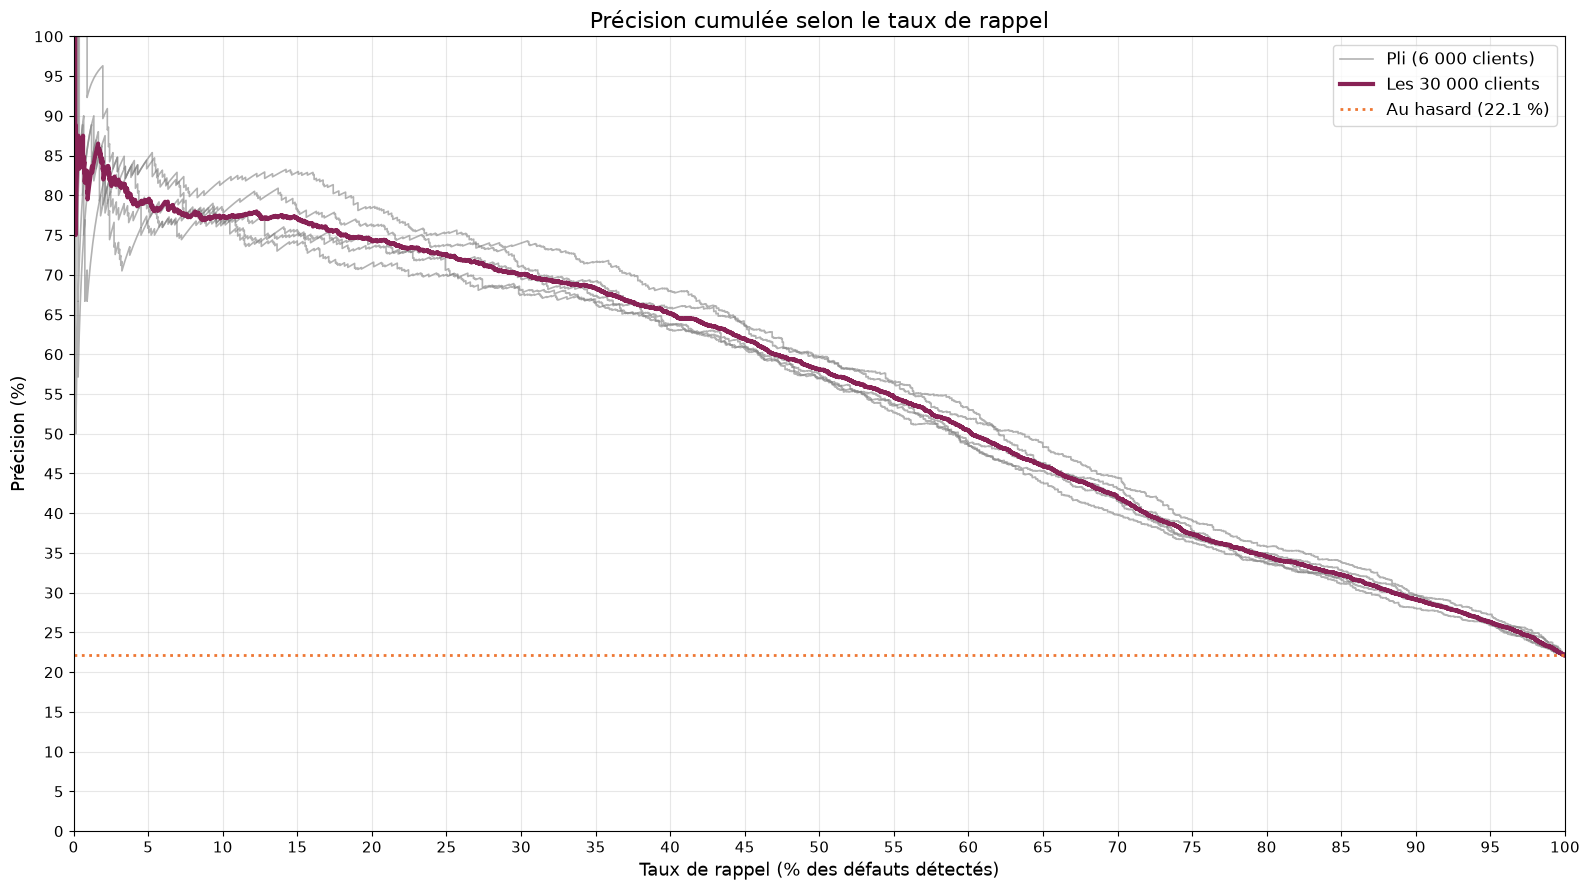

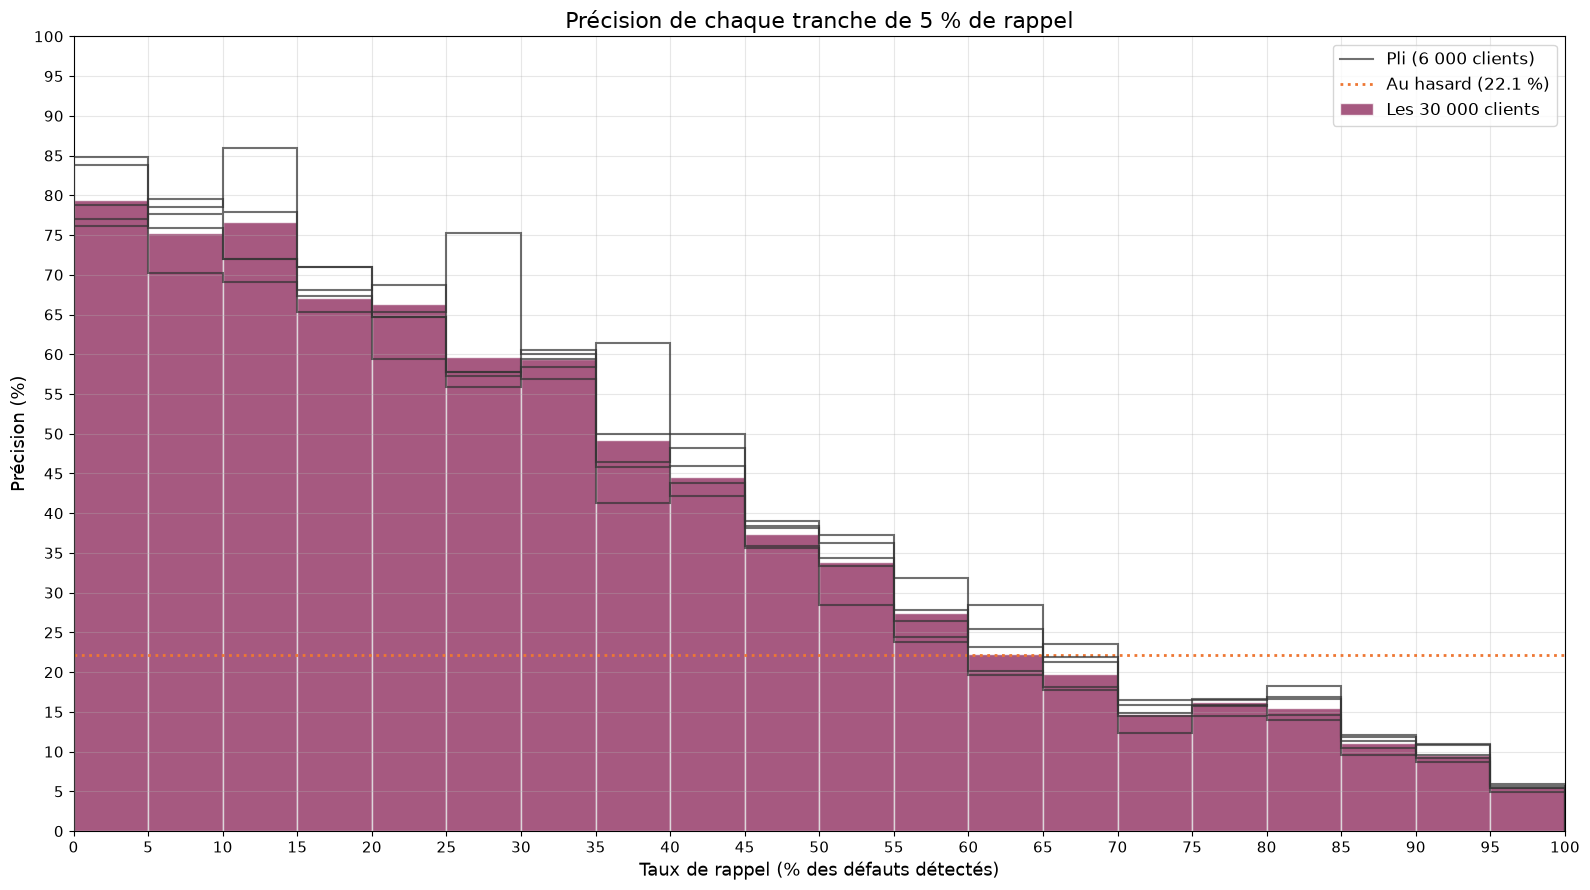

In [52]:
import matplotlib.pyplot as plt

PAS_FIN, PAS = 0.01, 0.05   # pas de la courbe cumulée (1 % de rappel) et largeur des tranches (5 %)

def courbe(y_vrai, p, pas=PAS):
    """Pour chaque taux de rappel (de pas en pas) : précision cumulée, précision de la tranche, part des clients signalés, score à atteindre."""
    ordre = np.argsort(-p)
    y_tri, p_tri = y_vrai[ordre], p[ordre]
    defauts_cumules = np.cumsum(y_tri)
    lignes, precedent = [], (0, 0)
    for r in np.arange(pas, 1 + 1e-9, pas):
        n = int(np.searchsorted(defauts_cumules, np.ceil(r * y_tri.sum())) + 1)   # clients à signaler pour atteindre ce rappel
        d = int(defauts_cumules[n - 1])
        lignes.append({"Taux de rappel (%)": round(r * 100, 1), "Précision cumulée (%)": d / n * 100,
                       "Précision de la tranche (%)": (d - precedent[1]) / max(n - precedent[0], 1) * 100,
                       "Clients signalés (%)": n / len(y_tri) * 100, "Score à atteindre": p_tri[n - 1]})
        precedent = (n, d)
    return pd.DataFrame(lignes).set_index("Taux de rappel (%)")

def courbe_continue(y_vrai, p):
    """Précision cumulée selon le taux de rappel, client par client (un point par client ajouté, du score le plus haut au plus bas)."""
    y_tri = y_vrai[np.argsort(-p)]
    defauts_cumules = np.cumsum(y_tri)
    return defauts_cumules / y_tri.sum() * 100, defauts_cumules / np.arange(1, len(y_tri) + 1) * 100

tous, tous_fin = courbe(y, proba), courbe(y, proba, PAS_FIN)
par_pli = {numero: courbe(y[validation], proba[validation]) for numero, (_, validation) in enumerate(plis, start=1)}

def mise_en_forme(ax, titre):
    ax.axhline(y.mean() * 100, color="#EE7733", ls=":", lw=2, label=f"Au hasard ({y.mean() * 100:.1f} %)")
    ax.set_title(titre, fontsize=16)
    ax.set_xlabel("Taux de rappel (% des défauts détectés)", fontsize=13); ax.set_ylabel("Précision (%)", fontsize=13)
    ax.set(xlim=(0, 100), ylim=(0, 100)); ax.set_xticks(range(0, 101, 5)); ax.set_yticks(range(0, 101, 5))
    ax.tick_params(labelsize=11); ax.grid(alpha=0.3); ax.legend(fontsize=12)
    plt.tight_layout(); plt.show()

# Graphique 1 : précision cumulée, client par client
fig, ax = plt.subplots(figsize=(16, 9))
for numero, (_, validation) in enumerate(plis, start=1):
    ax.plot(*courbe_continue(y[validation], proba[validation]), color="grey", alpha=0.6, lw=1.2, label="Pli (6 000 clients)" if numero == 1 else None)
ax.plot(*courbe_continue(y, proba), color="#882255", lw=3, label="Les 30 000 clients")
mise_en_forme(ax, "Précision cumulée selon le taux de rappel")

# Graphique 2 : précision de chaque tranche de taux de rappel
fig, ax = plt.subplots(figsize=(16, 9))
ax.bar(tous.index - PAS * 100, tous["Précision de la tranche (%)"], width=PAS * 100, align="edge", color="#882255", alpha=0.75,
       edgecolor="white", label="Les 30 000 clients")   # une barre par tranche, de sa borne basse à sa borne haute
for numero, c in par_pli.items():
    # Chaque pli : un palier horizontal par tranche, sur toute sa largeur
    ax.stairs(c["Précision de la tranche (%)"], np.r_[0, c.index], color="#333333", alpha=0.7, lw=1.5, zorder=3,
              label="Pli (6 000 clients)" if numero == 1 else None)
mise_en_forme(ax, f"Précision de chaque tranche de {PAS * 100:.0f} % de rappel")


**Les chiffres de la courbe des 30 000 clients**, pour placer les bornes (la précision de la tranche, plus 5 colonnes pour celle de chaque pli : un palier réel y apparaît partout) :

In [53]:
# Tête de liste, de 1 % en 1 % (rappel de 1 à 4 %), puis de 5 % en 5 %
tete = tous_fin.loc[[1.0, 2.0, 3.0, 4.0], ["Précision cumulée (%)", "Clients signalés (%)", "Score à atteindre"]]
display(Markdown("**Tête de liste, de 1 % en 1 % de rappel**"))
display(tete.round({"Précision cumulée (%)": 1, "Clients signalés (%)": 2, "Score à atteindre": 3}))
display(Markdown("**De 5 % en 5 % de rappel**"))
lecture = tous.round({"Précision cumulée (%)": 1, "Précision de la tranche (%)": 1, "Clients signalés (%)": 1, "Score à atteindre": 3})
for numero, c in par_pli.items():
    lecture[f"Tranche, pli {numero} (%)"] = c["Précision de la tranche (%)"].round(1)
display(lecture)

**Tête de liste, de 1 % en 1 % de rappel**

,Précision cumulée (%),Clients signalés (%),Score à atteindre
Taux de rappel (%),,,
1.0,80.7,0.28,0.936
2.0,82.1,0.54,0.932
3.0,82.0,0.81,0.929
4.0,78.9,1.12,0.925


**De 5 % en 5 % de rappel**

,Précision cumulée (%),Précision de la tranche (%),Clients signalés (%),Score à atteindre,"Tranche, pli 1 (%)","Tranche, pli 2 (%)","Tranche, pli 3 (%)","Tranche, pli 4 (%)","Tranche, pli 5 (%)"
Taux de rappel (%),,,,,,,,,
5.0,79.4,79.4,1.4,0.923,76.1,83.8,78.8,77.0,84.8
10.0,77.3,75.3,2.9,0.911,77.6,70.2,75.9,79.5,78.6
15.0,77.1,76.7,4.3,0.894,72.0,69.1,72.0,77.9,85.9
20.0,74.3,67.1,6.0,0.873,71.0,65.3,68.0,71.0,67.3
25.0,72.6,66.3,7.6,0.854,59.5,64.7,68.8,65.3,64.7
30.0,70.1,59.7,9.5,0.833,57.8,57.3,57.8,75.3,55.8
35.0,68.3,59.4,11.3,0.797,58.4,60.6,56.9,60.0,59.5
40.0,65.2,49.3,13.6,0.738,61.5,46.5,45.8,50.0,41.2
45.0,62.0,44.5,16.1,0.683,50.0,48.2,45.9,42.1,43.8


**Comment lire** :
- **un palier** : plusieurs tranches de suite à une précision proche, dans les 30 000 clients **et** dans les 5 plis ; la borne se place à la fin du palier, avant le décrochage ;
- **la ligne droite** : à partir du moment où la précision de la tranche baisse régulièrement, le reste du taux de rappel est découpé en tranches égales ;
- **la colonne « Score à atteindre »** donne, pour chaque borne choisie en taux de rappel, le score correspondant : c'est lui qui servira à classer un client.

**Bornes retenues** (lecture humaine des courbes des 30 000 clients et des 5 plis, le 08/10/2026) :
- **classe 9 (la plus risquée) : 0 à 15 % de rappel**, le premier palier, évident (précision des tranches autour de 77 %) ;
- **classe 8 : 15 à 25 %**, deuxième palier (autour de 67 %) ;
- **classe 7 : 25 à 35 %**, troisième palier (autour de 60 %) ;
- **classes 6 à 2 : de 35 à 60 %, en tranches égales de 5 %**, là où la précision descend en ligne droite ; c'est dans cette zone que la banque choisit jusqu'où elle signale ;
- **au-delà de 60 % : classe 1, client non déclaré en défaut.** La précision de chaque tranche y passe **sous le hasard** (le taux de défaut du dataset) : déclarer ces clients en défaut serait moins juste qu'un tirage au sort.

**Numérotation** : comme dans l'usage bancaire, le chiffre augmente avec le risque (classe 9 la plus risquée, classe 1 les non déclarés).

**Comment lire les classes** :
- **de la classe 9 à la classe 2, le risque est élevé tout le long, et bien échelonné.** Chaque classe fait défaut plus souvent que la suivante, sans plateau de risque, et toutes restent au-dessus du hasard. Les classes 9, 8 et 7 sont les plus risquées : la majorité de leurs clients font défaut ;
- **c'est sur cette échelle que la banque choisit jusqu'où elle intervient.** Chaque classe ajoutée détecte plus de défauts, mais fait aussi signaler plus de clients qui, en réalité, paieront : c'est le coût des faux positifs, à mettre en regard des défauts en plus ;
- **classe 1 : très peu risquée, les clients sains** aux yeux du modèle. Leur taux de défaut est bien sous la moyenne, mais le modèle ne sait plus y repérer les rares défauts.

## 9. Les classes de risque : seuils, vérification, enregistrement

Chaque borne retenue en taux de rappel devient un **seuil de score** : le score à atteindre, sur la courbe des 30 000 clients, pour détecter cette part des défauts. Un client est rangé dans la classe la plus risquée dont il atteint le seuil ; sous le seuil de 60 %, il est en classe 1 (non déclaré en défaut).

**Vérification** : le taux de défaut constaté de chaque classe, sur les 30 000 clients puis dans chacun des 5 plis (6 000 clients non vus chacun). Des taux proches d'un pli à l'autre veulent dire que les classes sont stables.

**Enregistrement**, pour la démonstration (page 7.4) : les seuils de score des classes et le taux de défaut constaté de chacune.

In [55]:
BORNES_RAPPEL = [15, 25, 35, 40, 45, 50, 55, 60]   # % de rappel (lecture humaine, étape 8), de la tête de liste vers la fin
# Numérotation de l'usage bancaire : le chiffre augmente avec le risque. Borne 15 % -> classe 9 (la plus risquée), ...,
# borne 60 % -> classe 2 ; classe 1 : non déclarés (au-delà de 60 % de rappel, précision sous le hasard)
CLASSE_DE_BORNE = {r: len(BORNES_RAPPEL) + 1 - i for i, r in enumerate(BORNES_RAPPEL)}
seuils = {}
ordre = np.argsort(-proba)
cumul = np.cumsum(y[ordre])
for r in BORNES_RAPPEL:
    n = int(np.searchsorted(cumul, np.ceil(r / 100 * y.sum())) + 1)
    seuils[r] = float(proba[ordre][n - 1])
classe = np.ones(len(y), dtype=int)                      # 1 : non déclarés
for r in reversed(BORNES_RAPPEL):                         # de la borne la plus basse à la plus haute : la classe la plus risquée l'emporte
    classe[proba >= seuils[r]] = CLASSE_DE_BORNE[r]

lignes = []
for i, r in enumerate(BORNES_RAPPEL):
    k = CLASSE_DE_BORNE[r]
    dans = classe == k
    ligne = {"Classe": k, "Rappel": f"{BORNES_RAPPEL[i - 1] if i > 0 else 0} à {r} %", "Seuil de score": round(seuils[r], 3),
             "Clients": int(dans.sum()), "Part des clients (%)": round(dans.mean() * 100, 1),
             "Taux de défaut constaté (%)": round(y[dans].mean() * 100, 1)}
    for numero, (_, validation) in enumerate(plis, start=1):
        d = dans[validation]
        ligne[f"Pli {numero} (%)"] = round(y[validation][d].mean() * 100, 1) if d.any() else None
    lignes.append(ligne)
dans = classe == 1
lignes.append({"Classe": 1, "Rappel": "au-delà de 60 % : non déclarés", "Seuil de score": None, "Clients": int(dans.sum()),
               "Part des clients (%)": round(dans.mean() * 100, 1), "Taux de défaut constaté (%)": round(y[dans].mean() * 100, 1),
               **{f"Pli {numero} (%)": round(y[validation][dans[validation]].mean() * 100, 1) for numero, (_, validation) in enumerate(plis, start=1)}})
display(Markdown(f"**Classes de risque**, de la plus risquée à la moins risquée (taux de défaut du dataset, le hasard : {y.mean() * 100:.1f} %)"))
display(pd.DataFrame(lignes).set_index("Classe"))

# Enregistrement pour la démonstration (page 7.4) : seuil de score de chaque classe, taux de défaut constaté de chacune
taux = {str(k): float(y[classe == k].mean()) for k in range(1, len(BORNES_RAPPEL) + 2)}
(dossier_demo / "demo_3_classes.json").write_text(json.dumps(
    {"bornes_rappel": BORNES_RAPPEL, "classe_de_borne": {str(r): k for r, k in CLASSE_DE_BORNE.items()},
     "seuils_score": {str(r): s for r, s in seuils.items()}, "taux_defaut_classes": taux, "taux_defaut_dataset": float(y.mean())},
    indent=2), encoding="utf-8")
display(Markdown("**Enregistré** : `demo_3_classes.json` (seuils de score et taux de défaut constaté des classes)"))


**Classes de risque**, de la plus risquée à la moins risquée (taux de défaut du dataset, le hasard : 22.1 %)

,Rappel,Seuil de score,Clients,Part des clients (%),Taux de défaut constaté (%),Pli 1 (%),Pli 2 (%),Pli 3 (%),Pli 4 (%),Pli 5 (%)
Classe,,,,,,,,,,
9,0 à 15 %,0.894,1292,4.3,77.1,75.0,74.2,75.5,78.9,82.0
8,15 à 25 %,0.854,994,3.3,66.7,68.5,64.1,68.8,66.8,65.1
7,25 à 35 %,0.797,1115,3.7,59.6,57.3,60.7,56.7,67.0,55.6
6,35 à 40 %,0.738,674,2.2,49.3,61.1,48.2,46.4,49.0,41.5
5,40 à 45 %,0.683,746,2.5,44.5,47.2,45.5,48.2,37.0,44.0
4,45 à 50 %,0.630,886,3.0,37.4,36.5,37.2,34.6,39.9,38.7
3,50 à 55 %,0.584,979,3.3,33.9,35.2,33.8,36.1,33.9,30.0
2,55 à 60 %,0.530,1211,4.0,27.4,28.1,25.9,25.1,29.1,28.7
1,au-delà de 60 % : non déclarés,NaN,22103,73.7,12.0,11.6,12.2,12.2,11.8,12.2


**Enregistré** : `demo_3_classes.json` (seuils de score et taux de défaut constaté des classes)

**Comment lire** : de la classe 9 à la classe 2, le taux de défaut doit baisser d'une classe à l'autre et rester au-dessus du hasard ; les clients de la classe 1 font défaut moins souvent que la moyenne. Les colonnes des plis montrent si chaque classe garde son taux sur des clients différents.